# 2. The particle in a box

This is the simplest system in which quantum mechanics says something classical
mechanics cannot: a particle confined between two walls can only have certain
energies.

The rule for getting from notebook 1's Hamiltonian to a quantum problem is short:

$$H(q,p) = \frac{p^2}{2m} + V(q)
\quad\longrightarrow\quad
\hat H = -\frac{\hbar^2}{2m}\frac{d^2}{dx^2} + V(x),$$

because momentum becomes the operator $\hat p = -i\hbar\,d/dx$, so
$\hat p^{\,2} = -\hbar^2 d^2/dx^2$. States are functions $\psi(x)$, and the ones
with a definite energy solve the **time-independent Schrödinger equation**

$$\hat H \psi = E\psi .$$

That is an eigenvalue problem: $\hat H$ is a linear operator on functions, $E$ is
a number, and $\psi$ is the eigenvector.

## 2.1 The Hamiltonian as a procedure

`scmutils` differentiates symbolically, and `D` is an *operator* -- it maps a
procedure to a procedure. So $\hat H$ can be written literally as what it is: a
function from wavefunctions to wavefunctions.

In [1]:
(define ((H-1d m hbar V) psi)
  (lambda (x)
    (+ (* (/ (* -1 (square hbar)) (* 2 m)) (((expt D 2) psi) x))
       (* (V x) (psi x)))))

H-1d 

Read it inside out: `((expt D 2) psi)` is $\psi''$, a procedure; applying it to
`x` gives $\psi''(x)$. Nothing here is specific to the box, so we reuse this
`H-1d` in notebook 3 for the oscillator.

Inside the box the potential is flat; take $V = 0$.

In [2]:
(define (V-box x) 0)
(define ((psi-sin k) x) (sin (* k x)))

V-box 
psi-sin 

## 2.2 Solving it

Apply $\hat H$ to $\sin(kx)$ and see what comes out. Everything stays symbolic --
$m$, $\hbar$ and $k$ are literal symbols.

In [3]:
%%show_expression
(((H-1d 'm 'hbar V-box) (psi-sin 'k)) 'x)

<IPython.core.display.Latex object>

That is $\frac{\hbar^2k^2}{2m}\sin(kx)$: the same function back, times a
constant. Divide to make the point unmistakably.

In [4]:
%%show_expression
(/ (((H-1d 'm 'hbar V-box) (psi-sin 'k)) 'x)
   ((psi-sin 'k) 'x))

<IPython.core.display.Latex object>

So $\sin(kx)$ is an eigenfunction for **any** $k$, with

$$E = \frac{\hbar^2 k^2}{2m},$$

which is just $p^2/2m$ with $p = \hbar k$ -- the de Broglie relation, falling out
rather than being assumed. So far nothing is quantized. Any $k$ works, so any
energy works.

## 2.3 Where the quantization comes from

The walls do it. The particle cannot be outside $[0,L]$, so $\psi$ must vanish at
both ends. $\psi(0) = \sin 0 = 0$ already. The condition at the far wall,

$$\psi(L) = \sin(kL) = 0,$$

holds only when $kL$ is a multiple of $\pi$:

$$k_n = \frac{n\pi}{L}, \qquad n = 1, 2, 3, \dots$$

and therefore

$$\boxed{\,E_n = \frac{n^2\pi^2\hbar^2}{2mL^2}\,}$$

**$n = 0$ is not allowed**, because $\sin(0 \cdot x)$ is identically zero and a
particle described by the zero function is nowhere at all. So the lowest energy
is $E_1 > 0$: the particle cannot be at rest. That is the zero-point energy, and
it is forced by confinement alone. Squeeze the box ($L$ small) and $E_1$ goes up
like $1/L^2$.

The normalization constant comes from $\int_0^L |\psi|^2 dx = 1$, giving
$\sqrt{2/L}$; we check that numerically below rather than asserting it.

In [5]:
(define ((psi-box L n) x) (* (sqrt (/ 2 L)) (sin (/ (* n pi x) L))))
(define (energy-box L n) (/ (* n n pi pi) (* 2 L L)))   ; hbar = m = 1

psi-box 
energy-box 

## 2.4 Checking normalization and orthogonality

The inner product of two real wavefunctions is
$\langle f | g \rangle = \int f(x)\,g(x)\,dx$. `definite-integral` takes the
integrand, the limits and a tolerance.

In [6]:
(define (inner-product f g a b)
  (definite-integral (lambda (x) (* (f x) (g x))) a b 1e-11))

(define L 1.)
(list 'n1.n1 (inner-product (psi-box L 1) (psi-box L 1) 0. L)
      'n3.n3 (inner-product (psi-box L 3) (psi-box L 3) 0. L)
      'n1.n2 (inner-product (psi-box L 1) (psi-box L 2) 0. L)
      'n2.n5 (inner-product (psi-box L 2) (psi-box L 5) 0. L))

inner-product 
L 
#|
(n1.n1 1.0000000000000002
       n3.n3
       1.0000000000000002
       n1.n2
       -2.3615855128413012e-17
       n2.n5
       0.)
|#

Each state has unit norm and different states are orthogonal to about $10^{-16}$.
This is not an accident of this particular system: eigenfunctions of a Hermitian
operator with different eigenvalues are always orthogonal, and that is what lets
us expand any state in this basis.

## 2.5 The wavefunctions

In [7]:
(define (plot-data win xs ys)
  (let loop ((xs xs) (ys ys))
    (if (and (pair? (cdr xs)) (pair? (cdr ys)))
        (begin (plot-line win (car xs) (car ys) (cadr xs) (cadr ys))
               (loop (cdr xs) (cdr ys))))))

plot-data 

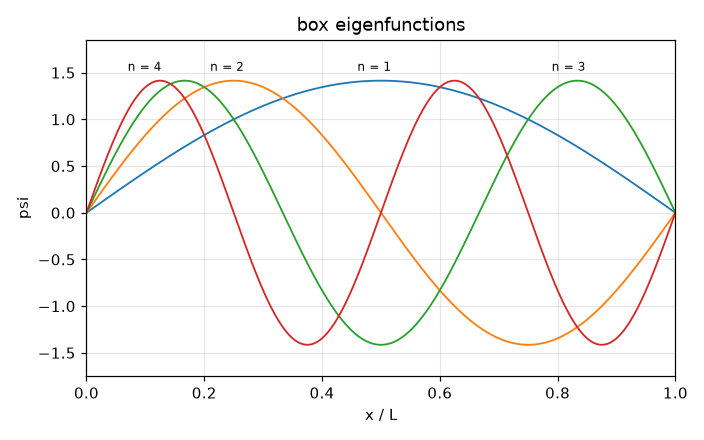

In [8]:
%%plot --title "box eigenfunctions" --xlabel "x / L" --ylabel "psi" --grid
(define win (frame 0. 1. -1.75 1.85))
(for-each (lambda (n) (plot-function win (psi-box 1. n) 0. 1. .002))
          (list 1 2 3 4))
(graphics-draw-text win .46 1.52 "n = 1")
(graphics-draw-text win .21 1.52 "n = 2")
(graphics-draw-text win .79 1.52 "n = 3")
(graphics-draw-text win .07 1.52 "n = 4")

State $n$ has $n-1$ interior zeros -- *nodes*. More nodes means more curvature,
and curvature is exactly what $-\tfrac{\hbar^2}{2m}\psi''$ charges energy for.
That is the mechanical reason the levels rise.

The physically meaningful quantity is $|\psi|^2$, the probability density.

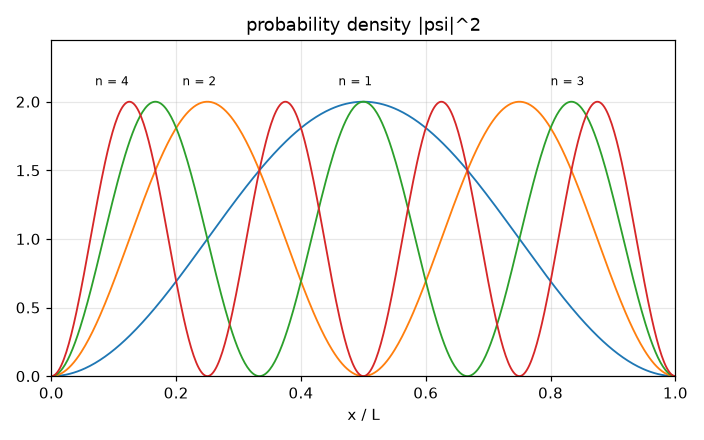

In [9]:
%%plot --title "probability density |psi|^2" --xlabel "x / L" --grid
(define win (frame 0. 1. 0. 2.45))
(for-each (lambda (n)
            (plot-function win (lambda (x) (square ((psi-box 1. n) x))) 0. 1. .002))
          (list 1 2 3 4))
(graphics-draw-text win .46 2.12 "n = 1")
(graphics-draw-text win .21 2.12 "n = 2")
(graphics-draw-text win .80 2.12 "n = 3")
(graphics-draw-text win .07 2.12 "n = 4")

In the ground state the particle is most likely near the middle. In $n = 2$ the
middle is a node -- the particle is *never* found at the centre of the box, which
has no classical counterpart at all.

## 2.6 The energy ladder

$E_n \propto n^2$, so the gaps widen as you go up.

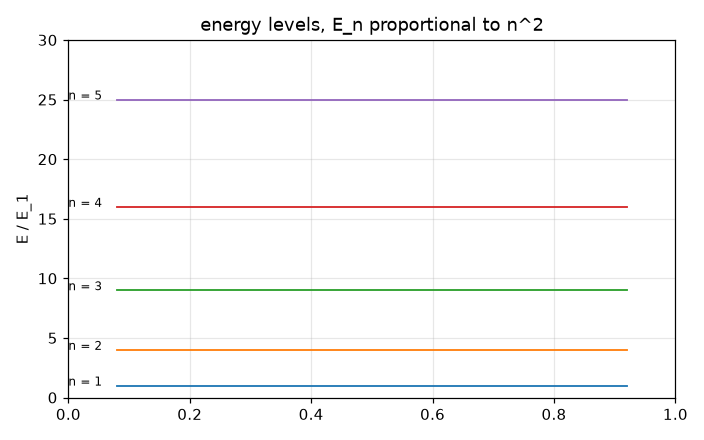

In [10]:
%%plot --title "energy levels, E_n proportional to n^2" --ylabel "E / E_1" --grid
(define win (frame 0. 1. 0. 30.))
(for-each (lambda (n) (plot-line win .08 (exact->inexact (* n n))
                                    .92 (exact->inexact (* n n))))
          (list 1 2 3 4 5))
(for-each (lambda (n)
            (graphics-draw-text win .0 (exact->inexact (* n n))
                                (string-append "n = " (number->string n))))
          (list 1 2 3 4 5))

## 2.7 Expectation values

An expectation value is the average of many measurements on identically prepared
systems:

$$\langle A \rangle = \int \psi^*(x)\, A\, \psi(x)\, dx .$$

For the ground state, symmetry says $\langle x\rangle = L/2$. The spread
$\Delta x = \sqrt{\langle x^2\rangle - \langle x\rangle^2}$ is a real prediction:

In [11]:
(define (average f L n)
  (definite-integral (lambda (x) (* (f x) (square ((psi-box L n) x)))) 0. L 1e-11))

(define x1  (average (lambda (x) x) 1. 1))
(define x21 (average square 1. 1))
(list 'mean-x x1
      'mean-x2 x21
      'variance (- x21 (square x1))
      'closed-form (- (/ 1. 12.) (/ 1. (* 2. (square pi)))))

average 
x1 
x21 
#|
(mean-x .5000000000000001
        mean-x2
        .2826727415121647
        variance
        3.2672741512164594e-2
        closed-form
        .03267274151216444)
|#

The variance matches the closed form $\frac{1}{12} - \frac{1}{2\pi^2}$, a bit
*smaller* than the $1/12$ a uniformly spread classical particle would have --
the ground state is bunched toward the centre.

## 2.8 The classical limit

Where does ordinary physics come back? A classical particle bouncing between the
walls is equally likely to be anywhere, so the chance of finding it in the left
third is exactly $1/3$. The quantum answer depends on $n$:

In [12]:
(define (prob-left-third n)
  (definite-integral (lambda (x) (square ((psi-box 1. n) x))) 0. (/ 1. 3.) 1e-11))

(map (lambda (n) (list n (prob-left-third n))) (list 1 2 3 10 30))

prob-left-third 
#|
((1 .19550110947788524) (2 .4022494452610574)
                        (3 .33333333333333337)
                        (10 .3195501109477905)
                        (30 .3333333333333331))
|#

$n = 1$ gives $0.196$, far from classical. By $n = 30$ it is $0.3333$. This is
**Bohr's correspondence principle**: quantum results reproduce classical ones at
large quantum numbers. Note $n = 3$ already gives exactly $1/3$ -- an integer
number of half-wavelengths happens to fit in a third of the box. Coincidences
like that are not the rule; the trend is.

Seen as a picture, the oscillations of $|\psi|^2$ survive at large $n$ but get so
fine that anything averaging over a small window sees the flat classical density.

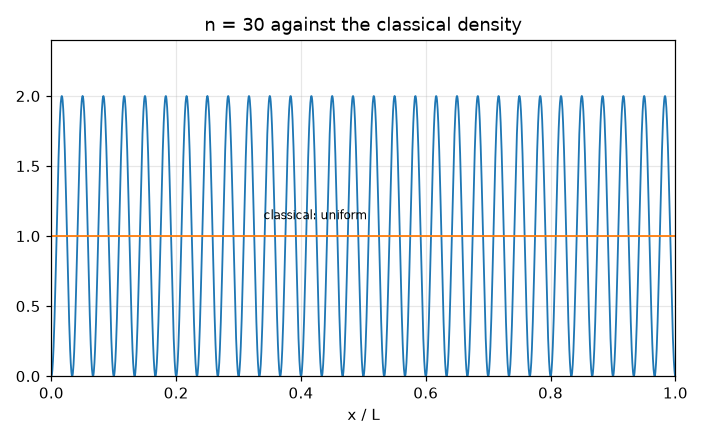

In [13]:
%%plot --title "n = 30 against the classical density" --xlabel "x / L" --grid
(define win (frame 0. 1. 0. 2.4))
(plot-function win (lambda (x) (square ((psi-box 1. 30) x))) 0. 1. .0005)
(plot-line win 0. 1. 1. 1.)
(graphics-draw-text win .34 1.12 "classical: uniform")

## What to carry forward

- $\hat H\psi = E\psi$ is an eigenvalue problem; energies are eigenvalues.
- Quantization comes from **boundary conditions**, not from the equation. The
  differential equation alone allows every $E$.
- Confinement forces a non-zero ground-state energy.
- Eigenfunctions are orthonormal, and large $n$ recovers classical behaviour.

Next: [the quantum harmonic oscillator](03-quantum-harmonic-oscillator.ipynb) --
the same machinery on notebook 1's Hamiltonian, where the confinement is a spring
instead of a wall.